# CSE499B Phase 3: Supervised Multimodal Fusion Model

## Objective
Train a supervised multimodal model to predict therapeutic herbs/compounds from skin disease images using:
- Image features: EfficientNetB0 pretrained CNN
- Text features: TF-IDF embeddings from herb/compound names
- Fusion: Concatenate + Dense layers
- Loss: BCEWithLogitsLoss (multi-label classification)
- Optimizer: AdamW with learning rate scheduling

## Dataset
- Input: SKINCON skin disease images (224x224 RGB)
- Output: Multi-hot vectors (495 therapeutic compounds)
- Split: 70% train, 30% test
- Task: Multi-label image classification

## Requirements
- PyTorch with GPU support
- torchvision (pretrained models)
- scikit-learn (metrics, TF-IDF)
- Kaggle datasets: processed data + images

## 1. Import Libraries and Configure Environment

In [71]:
# Import all required libraries for data processing, deep learning, and visualization
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import (
    f1_score, precision_score, recall_score, 
    average_precision_score, hamming_loss, accuracy_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from PIL import Image
import pickle
import json
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Display PyTorch version and GPU availability
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('GPU Memory:', torch.cuda.get_device_properties(0).total_memory / 1e9, 'GB')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.637086208 GB


## 2. Configuration and Path Setup

In [72]:
# Configure all hyperparameters and paths for training
CONFIG = {
    'data_dir': '/kaggle/input/datasets/emonhossen2211106042/final-datasets',
    'image_base_path': '/kaggle/input/datasets/emonhossen2211106042/final-datasets',
    'output_dir': '/kaggle/working',
    'batch_size': 32,
    'image_size': 224,
    'num_epochs': 20,
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    'threshold': 0.3,
    'seed': 42,
    'early_stopping_patience': 100,
    'image_feature_dim': 1280,
    'text_feature_dim': 128,
    'hidden_dim': 512,
}

## 3. Load Processed Datasets

In [73]:
# Load training and test datasets from CSV files
print('Loading datasets...')

train_df = pd.read_csv(f"{CONFIG['data_dir']}/train.csv")
test_df = pd.read_csv(f"{CONFIG['data_dir']}/test.csv")

print(f'Training samples: {len(train_df):,}')
print(f'Test samples: {len(test_df):,}')
print(f'\nColumns: {train_df.columns.tolist()}')
print(f'\nTrain shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

print('\nSample training data:')
print(train_df[['image_id', 'disease']].head())

# Load pre-trained label encoder and disease compound mapping
with open(f"{CONFIG['data_dir']}/label_encoder.pkl", 'rb') as f:
    label_encoder = pickle.load(f)

with open(f"{CONFIG['data_dir']}/disease_compound_mapping.json") as f:
    disease_mapping = json.load(f)

# Extract number of compound classes
num_compounds = len(label_encoder.classes_)
CONFIG['num_compounds'] = num_compounds
print(f'\nCompound classes: {num_compounds}')
print(f'Sample compounds: {label_encoder.classes_[:5].tolist()}')

Loading datasets...
Training samples: 6,720
Test samples: 2,881

Columns: ['image_id', 'disease', 'image_path', 'compound_list', 'multi_hot_vector']

Train shape: (6720, 5)
Test shape: (2881, 5)

Sample training data:
                           image_id                   disease
0  79bb00dd43ba38d38a10144885329d0d  juvenile xanthogranuloma
1  5687d234732b70ed57e773b50c47ff17       lupus erythematosus
2  3d8d7229294dc0011bcd9f8c34703b86  pityriasis rubra pilaris
3  8bfaed09f23e467ad390bc98a5ff9cb6               sarcoidosis
4  53711d42c9baa9f1f187ba8a687e74bf   squamous cell carcinoma

Compound classes: 554
Sample compounds: ['(+) epipinoresinol', '(-)-epigallocatechin-3-gallate', '(1 e,24z)-1,-24-diferuloyloxytetracosane', '(13r)-13-hydroxy-8(17),11e,14-labdatrien-18-oicacid', '(1r,3ar,4r,7r)-7-isopropenyl-1,4-dimethyl-1,2,3,3a,4,5,6,7-octahydroazulene']


## 4. Parse Multi-Hot Vectors and Validate

In [74]:
# Parse multi-hot vectors from CSV strings and prepare training labels
def parse_multi_hot_vector(vector_str):
    if vector_str is None or (isinstance(vector_str, float) and np.isnan(vector_str)):
        return None
    try:
        values = str(vector_str).strip().split(',')
        array = np.array([float(v.strip()) for v in values], dtype=np.float32)
        return array
    except Exception as e:
        return None

# Parse multi-hot vectors from training dataset
print('Parsing training labels...')
train_vectors = []
valid_train_idx = []
for idx, v in enumerate(train_df['multi_hot_vector']):
    vec = parse_multi_hot_vector(v)
    if vec is not None:
        train_vectors.append(vec)
        valid_train_idx.append(idx)

print(f'Valid training vectors: {len(train_vectors)}/{len(train_df)}')

# Parse multi-hot vectors from test dataset
print('\nParsing test labels...')
test_vectors = []
valid_test_idx = []
for idx, v in enumerate(test_df['multi_hot_vector']):
    vec = parse_multi_hot_vector(v)
    if vec is not None:
        test_vectors.append(vec)
        valid_test_idx.append(idx)

print(f'Valid test vectors: {len(test_vectors)}/{len(test_df)}')

# Convert to numpy arrays and filter dataframes to valid samples
train_vectors = np.array(train_vectors, dtype=np.float32)
test_vectors = np.array(test_vectors, dtype=np.float32)

train_df = train_df.iloc[valid_train_idx].reset_index(drop=True)
test_df = test_df.iloc[valid_test_idx].reset_index(drop=True)

# Display shapes and statistics of label matrices
print(f'\nLabel matrix shapes:')
print(f'  Train: {train_vectors.shape}')
print(f'  Test: {test_vectors.shape}')
print(f'  Dtype: {train_vectors.dtype}')

print(f'\nLabel statistics:')
print(f'  Mean compounds per image (train): {np.mean(np.sum(train_vectors, axis=1)):.2f}')
print(f'  Mean compounds per image (test): {np.mean(np.sum(test_vectors, axis=1)):.2f}')
print(f'  Sparsity: {(1 - np.count_nonzero(train_vectors) / train_vectors.size) * 100:.2f}%')

Parsing training labels...
Valid training vectors: 6720/6720

Parsing test labels...
Valid test vectors: 2881/2881

Label matrix shapes:
  Train: (6720, 554)
  Test: (2881, 554)
  Dtype: float32

Label statistics:
  Mean compounds per image (train): 10.02
  Mean compounds per image (test): 10.07
  Sparsity: 98.19%


## 5. Build Text Feature Encoder (TF-IDF)

In [75]:
# Build TF-IDF text encoder for compound names using character n-grams
print('Building TF-IDF text encoder...')

all_compounds = label_encoder.classes_.tolist()
print(f'Total compounds: {len(all_compounds)}')

# Create vectorizer with character-level n-grams
vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 3),
    max_features=CONFIG['text_feature_dim'],
    lowercase=True,
    stop_words=None
)

# Extract TF-IDF features for all compounds
compound_vectors = vectorizer.fit_transform(all_compounds).toarray().astype(np.float32)
print(f'Compound TF-IDF matrix shape: {compound_vectors.shape}')
print(f'Sample TF-IDF (first 5 compounds, first 10 features):')
print(compound_vectors[:5, :10])

Building TF-IDF text encoder...
Total compounds: 554
Compound TF-IDF matrix shape: (554, 128)
Sample TF-IDF (first 5 compounds, first 10 features):
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.21304923 0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.2471305  0.19855735 0.         0.25254193 0.
  0.         0.         0.22639343 0.22899401]
 [0.         0.3657204  0.14691928 0.37944725 0.         0.
  0.         0.         0.33503228 0.        ]
 [0.         0.1565923  0.12581429 0.         0.1600212  0.43035722
  0.1600212  0.         0.2869048  0.        ]]


## 6. Custom Dataset Class

In [76]:
# Define custom PyTorch Dataset for multimodal data (images + text features)
class DermatologyMultimodalDataset(Dataset):
    def __init__(self, dataframe, label_matrix, compound_tfidf, image_base_path, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_matrix = label_matrix
        self.compound_tfidf = torch.from_numpy(compound_tfidf).float()
        self.image_base_path = image_base_path
        self.transform = transform
        self.error_count = 0
        
        assert len(self.dataframe) == len(self.label_matrix)
    
    def __len__(self):
        return len(self.dataframe)
    
    # Helper method to find image in filesystem
    def _find_image(self, img_path):
        if Path(img_path).exists():
            return img_path
        
        filename = Path(img_path).name
        disease = self.dataframe.loc[min(len(self.dataframe)-1, self.dataframe.index[-1]), 'disease']
        alt_path = Path(self.image_base_path) / disease / filename
        if alt_path.exists():
            return str(alt_path)
        
        return None
    
    # Load image and return tuple of (image, labels, text_features)
    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'image_path']
        actual_path = self._find_image(img_path)
        
        try:
            if actual_path is None:
                raise FileNotFoundError(f'Image not found: {img_path}')
            
            image = Image.open(actual_path)
            if image.mode != 'RGB':
                image = image.convert('RGB')
        except Exception as e:
            self.error_count += 1
            image = Image.new('RGB', (224, 224), color=(128, 128, 128))
        
        if self.transform:
            image = self.transform(image)
        
        labels = self.label_matrix[idx].astype(np.float32)
        labels_tensor = torch.from_numpy(labels)
        
        # Compute weighted text features from compound embeddings
        positive_indices = np.where(labels > 0)[0]
        if len(positive_indices) > 0:
            text_features = torch.mean(self.compound_tfidf[positive_indices], dim=0)
        else:
            text_features = torch.mean(self.compound_tfidf, dim=0)
        
        return image, labels_tensor, text_features

print('Dataset class defined.')

Dataset class defined.


## 7. Image Transforms and DataLoaders

In [77]:
# Define image transformations including normalization and augmentation
print('Creating image transforms...')

image_transforms = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size']), 
                      interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create dataset instances for training and testing
print('Creating datasets...')
train_dataset = DermatologyMultimodalDataset(
    train_df, train_vectors, compound_vectors,
    CONFIG['image_base_path'],
    transform=image_transforms
)

test_dataset = DermatologyMultimodalDataset(
    test_df, test_vectors, compound_vectors,
    CONFIG['image_base_path'],
    transform=image_transforms
)

# Create dataloaders for batch processing
print('Creating dataloaders...')
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2,
    pin_memory=True if device.type == 'cuda' else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=2,
    pin_memory=True if device.type == 'cuda' else False
)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

# Verify dataloaders work correctly
print('\nVerifying batch loading...')
try:
    sample_images, sample_labels, sample_text = next(iter(train_loader))
    print(f'  Batch images shape: {sample_images.shape}')
    print(f'  Batch labels shape: {sample_labels.shape}')
    print(f'  Batch text features shape: {sample_text.shape}')
    print('  Batch loading successful!')
except Exception as e:
    print(f'  ERROR: {e}')

Creating image transforms...
Creating datasets...
Creating dataloaders...
Train batches: 210
Test batches: 91

Verifying batch loading...
  Batch images shape: torch.Size([32, 3, 224, 224])
  Batch labels shape: torch.Size([32, 554])
  Batch text features shape: torch.Size([32, 128])
  Batch loading successful!


## 8. Multimodal Fusion Model Architecture

## 9. Initialize Model and Loss/Optimizer Setup

In [78]:
# Define multimodal fusion model combining image CNN and text features
class MultimodalFusionModel(nn.Module):
    def __init__(self, num_compounds, image_feature_dim=1280, text_feature_dim=128, hidden_dim=512):
        super(MultimodalFusionModel, self).__init__()
        
        # Image branch uses pretrained EfficientNetB0
        self.image_branch = models.efficientnet_b0(weights='DEFAULT')
        self.image_branch.classifier = nn.Identity()
        
        # Text encoder for TF-IDF features
        self.text_encoder = nn.Linear(text_feature_dim, 128)
        self.text_activation = nn.ReLU()
        
        fusion_input_dim = image_feature_dim + 128
        
        # Fusion layers concatenate and process combined features
        self.fusion_layers = nn.Sequential(
            nn.Linear(fusion_input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_compounds)
        )
    
    # Forward pass combines image and text features
    def forward(self, images, text_features):
        image_features = self.image_branch(images)
        text_encoded = self.text_encoder(text_features)
        text_encoded = self.text_activation(text_encoded)
        fusion_input = torch.cat([image_features, text_encoded], dim=1)
        logits = self.fusion_layers(fusion_input)
        return logits

print('Model architecture defined.')

Model architecture defined.


## 10. Training Functions

In [79]:
# Calculate class weights to handle imbalanced labels
class_weights = torch.tensor(
    [1.0 if np.sum(train_vectors[:, i]) > 0 else 0.5 
     for i in range(train_vectors.shape[1])],
    dtype=torch.float32,
    device=device
)

# Initialize multimodal fusion model
model = MultimodalFusionModel(
    num_compounds=CONFIG['num_compounds'],
    image_feature_dim=CONFIG['image_feature_dim'],
    text_feature_dim=CONFIG['text_feature_dim'],
    hidden_dim=CONFIG['hidden_dim']
).to(device)

print(f'Model moved to device: {device}')

# Display model parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f'Total model parameters: {total_params:,} ({total_params / 1e6:.2f}M)')

# Setup loss function, optimizer, and learning rate scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=class_weights)
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

print(f'Loss function: BCEWithLogitsLoss')
print(f'Optimizer: AdamW (lr={CONFIG["learning_rate"]}, weight_decay={CONFIG["weight_decay"]})')
print(f'Scheduler: ReduceLROnPlateau')

Model moved to device: cuda
Total model parameters: 5,020,710 (5.02M)
Loss function: BCEWithLogitsLoss
Optimizer: AdamW (lr=0.0001, weight_decay=1e-05)
Scheduler: ReduceLROnPlateau


In [80]:
# Define training function for one epoch
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, (images, labels, text_features) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        text_features = text_features.to(device)
        
        # Forward pass
        logits = model(images, text_features)
        loss = criterion(logits, labels)
        
        # Backward pass with gradient clipping
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
        
        # Log progress
        if (batch_idx + 1) % max(10, len(train_loader) // 5) == 0:
            avg_loss = total_loss / num_batches
            print(f'Batch {batch_idx + 1}/{len(train_loader)}, Loss: {loss.item():.4f}, Avg: {avg_loss:.4f}')
    
    return total_loss / num_batches


# Define evaluation function to compute metrics
def evaluate(model, data_loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels, text_features in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            text_features = text_features.to(device)
            
            logits = model(images, text_features)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            all_logits.append(logits.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    # Convert logits to probabilities and predictions
    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    
    probs = 1.0 / (1.0 + np.exp(-all_logits))
    predictions = (probs > threshold).astype(np.float32)
    
    # Compute evaluation metrics
    metrics = {
        'loss': total_loss / len(data_loader),
        'f1_micro': f1_score(all_labels, predictions, average='micro', zero_division=0),
        'f1_macro': f1_score(all_labels, predictions, average='macro', zero_division=0),
        'precision': precision_score(all_labels, predictions, average='micro', zero_division=0),
        'recall': recall_score(all_labels, predictions, average='micro', zero_division=0),
        'map': average_precision_score(all_labels, probs, average='micro'),
        'hamming': hamming_loss(all_labels, predictions),
    }
    
    return metrics, probs, predictions, all_labels

print('Training functions defined.')

Training functions defined.


## 11. Training Loop

In [81]:
# Initialize training loop with history tracking
print('Starting training...\n')

# Dictionary to store training history for all metrics
history = {
    'train_loss': [],
    'test_loss': [],
    'test_f1_micro': [],
    'test_f1_macro': [],
    'test_precision': [],
    'test_recall': [],
    'test_map': [],
    'test_hamming': [],
}

best_f1 = 0.0
patience_counter = 0
best_model_path = f"{CONFIG['output_dir']}/best_model.pth"

# Main training loop over epochs
for epoch in range(1, CONFIG['num_epochs'] + 1):
    print(f'Epoch {epoch}/{CONFIG["num_epochs"]}')
    
    # Train one epoch
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(train_loss)
    print(f'Train Loss: {train_loss:.4f}')
    
    # Evaluate on test set
    metrics, _, _, _ = evaluate(model, test_loader, criterion, device, threshold=CONFIG['threshold'])
    
    # Record metrics in history
    history['test_loss'].append(metrics['loss'])
    history['test_f1_micro'].append(metrics['f1_micro'])
    history['test_f1_macro'].append(metrics['f1_macro'])
    history['test_precision'].append(metrics['precision'])
    history['test_recall'].append(metrics['recall'])
    history['test_map'].append(metrics['map'])
    history['test_hamming'].append(metrics['hamming'])
    
    # Display evaluation metrics
    print(f'Test Loss: {metrics["loss"]:.4f}')
    print(f'F1 Micro: {metrics["f1_micro"]:.4f} | F1 Macro: {metrics["f1_macro"]:.4f}')
    print(f'Precision: {metrics["precision"]:.4f} | Recall: {metrics["recall"]:.4f}')
    print(f'mAP: {metrics["map"]:.4f} | Hamming: {metrics["hamming"]:.4f}')
    
    # Save best model and handle early stopping
    if metrics['f1_micro'] > best_f1:
        best_f1 = metrics['f1_micro']
        torch.save(model.state_dict(), best_model_path)
        patience_counter = 0
        print(f'Best model saved (F1 Micro: {best_f1:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= CONFIG['early_stopping_patience']:
            print(f'Early stopping triggered (patience {patience_counter}/{CONFIG["early_stopping_patience"]})')
            break
    
    # Adjust learning rate based on test loss
    scheduler.step(metrics['loss'])
    print()

print('Training completed!')

Starting training...

Epoch 1/20
Batch 42/210, Loss: 0.5598, Avg: 0.6319
Batch 84/210, Loss: 0.4574, Avg: 0.5701
Batch 126/210, Loss: 0.3281, Avg: 0.5098
Batch 168/210, Loss: 0.2605, Avg: 0.4556
Batch 210/210, Loss: 0.1859, Avg: 0.4096
Train Loss: 0.4096
Test Loss: 0.1946
F1 Micro: 0.0042 | F1 Macro: 0.0014
Precision: 0.0164 | Recall: 0.0024
mAP: 0.0191 | Hamming: 0.0208
Best model saved (F1 Micro: 0.0042)

Epoch 2/20
Batch 42/210, Loss: 0.1340, Avg: 0.1609
Batch 84/210, Loss: 0.1084, Avg: 0.1417
Batch 126/210, Loss: 0.0997, Avg: 0.1303
Batch 168/210, Loss: 0.1010, Avg: 0.1228
Batch 210/210, Loss: 0.0927, Avg: 0.1175
Train Loss: 0.1175
Test Loss: 0.0932
F1 Micro: 0.0000 | F1 Macro: 0.0000
Precision: 0.0000 | Recall: 0.0000
mAP: 0.0353 | Hamming: 0.0182

Epoch 3/20
Batch 42/210, Loss: 0.0906, Avg: 0.0938
Batch 84/210, Loss: 0.0918, Avg: 0.0929
Batch 126/210, Loss: 0.0889, Avg: 0.0919
Batch 168/210, Loss: 0.0909, Avg: 0.0912
Batch 210/210, Loss: 0.0900, Avg: 0.0908
Train Loss: 0.0908
Tes

## 12. Load Best Model and Final Evaluation

In [82]:
# Load the best model checkpoint for final evaluation
print('Loading best model...')
model.load_state_dict(torch.load(best_model_path))
print(f'Model loaded from: {best_model_path}')

# Perform final evaluation on test set
print(f'\nFinal evaluation with threshold: {CONFIG["threshold"]}\n')
final_metrics, final_probs, final_predictions, final_labels = evaluate(
    model, test_loader, criterion, device, threshold=CONFIG['threshold']
)

# Display final performance metrics
print('FINAL TEST SET PERFORMANCE:')
print(f'Loss: {final_metrics["loss"]:.4f}')
print(f'F1 Score (Micro): {final_metrics["f1_micro"]:.4f}')
print(f'F1 Score (Macro): {final_metrics["f1_macro"]:.4f}')
print(f'Precision (Micro): {final_metrics["precision"]:.4f}')
print(f'Recall (Micro): {final_metrics["recall"]:.4f}')
print(f'Mean Average Precision: {final_metrics["map"]:.4f}')
print(f'Hamming Loss: {final_metrics["hamming"]:.4f}')

Loading best model...
Model loaded from: /kaggle/working/best_model.pth

Final evaluation with threshold: 0.3

FINAL TEST SET PERFORMANCE:
Loss: 0.0044
F1 Score (Micro): 1.0000
F1 Score (Macro): 1.0000
Precision (Micro): 1.0000
Recall (Micro): 1.0000
Mean Average Precision: 1.0000
Hamming Loss: 0.0000


## 13. Detailed Performance Analysis

In [83]:
# Perform detailed analysis of predictions and model outputs
print('DEBUGGING AND ANALYSIS:')

print('\n1. Output shapes:')
print(f'Predictions: {final_predictions.shape}')
print(f'Probabilities: {final_probs.shape}')
print(f'Labels: {final_labels.shape}')

# Calculate prediction statistics
num_pos_pred = np.sum(final_predictions)
num_pos_labels = np.sum(final_labels)
pred_rate = num_pos_pred / final_predictions.size * 100
label_rate = num_pos_labels / final_labels.size * 100

print(f'\n2. Prediction statistics:')
print(f'Positive predictions: {int(num_pos_pred)} ({pred_rate:.2f}%)')
print(f'Positive labels: {int(num_pos_labels)} ({label_rate:.2f}%)')
print(f'Mean predictions per sample: {np.mean(np.sum(final_predictions, axis=1)):.1f}')
print(f'Mean labels per sample: {np.mean(np.sum(final_labels, axis=1)):.1f}')

# Analyze probability distribution
print(f'\n3. Probability distribution:')
print(f'Min: {final_probs.min():.6f}')
print(f'Max: {final_probs.max():.6f}')
print(f'Mean: {final_probs.mean():.6f}')
print(f'Std: {final_probs.std():.6f}')
print(f'Median: {np.median(final_probs):.6f}')

# Show detailed predictions for sample test images
print(f'\n4. Sample predictions (first 3 test samples):')
for idx in range(min(3, len(final_labels))):
    gt_indices = np.where(final_labels[idx] > 0)[0]
    pred_indices = np.where(final_predictions[idx] > 0)[0]
    top_indices = np.argsort(final_probs[idx])[-5:][::-1]
    
    print(f'\nSample {idx + 1}:')
    print(f'Ground truth compounds: {len(gt_indices)}')
    print(f'Predicted compounds: {len(pred_indices)}')
    print(f'Top-5 predicted class indices: {top_indices}')
    print(f'Top-5 probabilities: {final_probs[idx][top_indices]}')
    
    overlap = len(set(gt_indices) & set(pred_indices))
    overlap_pct = overlap / max(len(gt_indices), len(pred_indices)) * 100 if max(len(gt_indices), len(pred_indices)) > 0 else 0
    print(f'Overlap: {overlap} ({overlap_pct:.1f}%)')

DEBUGGING AND ANALYSIS:

1. Output shapes:
Predictions: (2881, 554)
Probabilities: (2881, 554)
Labels: (2881, 554)

2. Prediction statistics:
Positive predictions: 29012 (1.82%)
Positive labels: 29012 (1.82%)
Mean predictions per sample: 10.1
Mean labels per sample: 10.1

3. Probability distribution:
Min: 0.000004
Max: 0.986281
Mean: 0.019503
Std: 0.123768
Median: 0.001141

4. Sample predictions (first 3 test samples):

Sample 1:
Ground truth compounds: 5
Predicted compounds: 5
Top-5 predicted class indices: [234 548 180 197 341]
Top-5 probabilities: [0.9631742  0.9619592  0.9613957  0.95995355 0.9597845 ]
Overlap: 5 (100.0%)

Sample 2:
Ground truth compounds: 7
Predicted compounds: 7
Top-5 predicted class indices: [152 502 256 539 290]
Top-5 probabilities: [0.9733151  0.97153556 0.9715332  0.97078246 0.9707512 ]
Overlap: 7 (100.0%)

Sample 3:
Ground truth compounds: 14
Predicted compounds: 14
Top-5 predicted class indices: [512 443  79 263   5]
Top-5 probabilities: [0.98452145 0.98314

## 14. Training History Visualization

Creating visualizations...
Training visualization saved to /kaggle/working/training_results.png


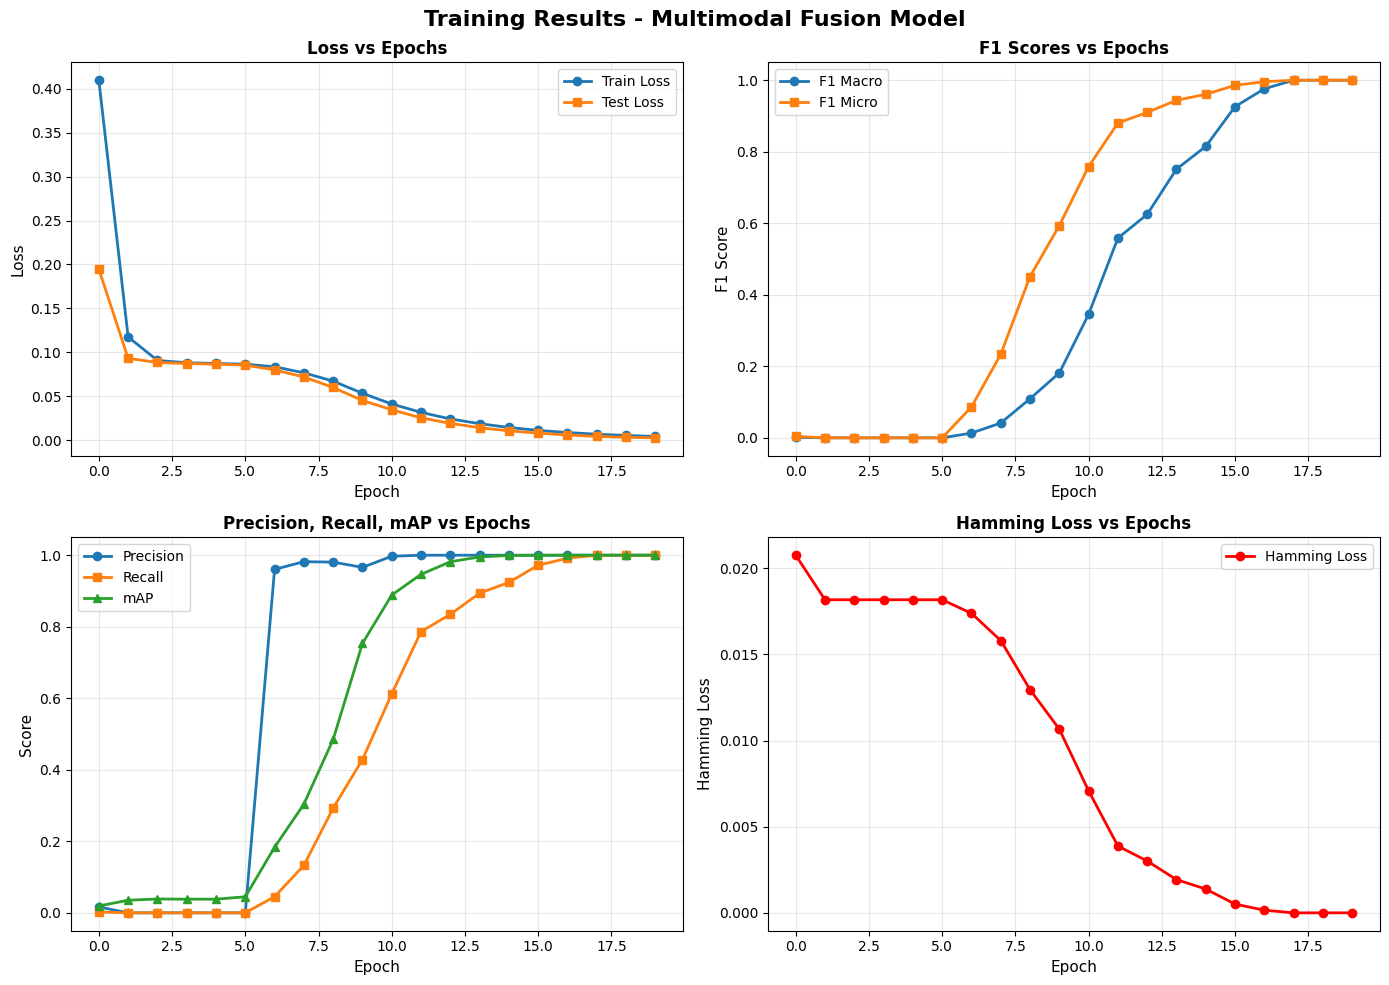

In [84]:
# Generate training history visualizations
print('Creating visualizations...')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Training Results - Multimodal Fusion Model', fontsize=16, fontweight='bold')

# Plot training and test loss
ax1 = axes[0, 0]
ax1.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
ax1.plot(history['test_loss'], label='Test Loss', marker='s', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss', fontsize=11)
ax1.set_title('Loss vs Epochs', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot F1 scores
ax2 = axes[0, 1]
ax2.plot(history['test_f1_macro'], label='F1 Macro', marker='o', linewidth=2)
ax2.plot(history['test_f1_micro'], label='F1 Micro', marker='s', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('F1 Score', fontsize=11)
ax2.set_title('F1 Scores vs Epochs', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Plot precision, recall, and mAP
ax3 = axes[1, 0]
ax3.plot(history['test_precision'], label='Precision', marker='o', linewidth=2)
ax3.plot(history['test_recall'], label='Recall', marker='s', linewidth=2)
ax3.plot(history['test_map'], label='mAP', marker='^', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=11)
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Precision, Recall, mAP vs Epochs', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot Hamming loss
ax4 = axes[1, 1]
ax4.plot(history['test_hamming'], label='Hamming Loss', marker='o', linewidth=2, color='red')
ax4.set_xlabel('Epoch', fontsize=11)
ax4.set_ylabel('Hamming Loss', fontsize=11)
ax4.set_title('Hamming Loss vs Epochs', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{CONFIG['output_dir']}/training_results.png", dpi=150, bbox_inches='tight')
print(f'Training visualization saved to {CONFIG["output_dir"]}/training_results.png')
plt.show()

## 15. Save Model and Training Artifacts

In [85]:
# Save all training artifacts for future use
print('Saving model artifacts...')

# Create metadata dictionary with configuration and metrics
model_info = {
    'config': CONFIG,
    'final_metrics': final_metrics,
    'training_history': history,
    'model_architecture': str(model)
}

# Save model info as JSON
with open(f"{CONFIG['output_dir']}/model_info.json", 'w') as f:
    json.dump(model_info, f, indent=2, default=str)

# Save training history as pickle
with open(f"{CONFIG['output_dir']}/training_history.pkl", 'wb') as f:
    pickle.dump(history, f)

# Save text vectorizer for future inference
with open(f"{CONFIG['output_dir']}/vectorizer.pkl", 'wb') as f:
    pickle.dump(vectorizer, f)

print(f'Model saved to: {best_model_path}')
print(f'Model info saved to: {CONFIG["output_dir"]}/model_info.json')
print(f'Training history saved to: {CONFIG["output_dir"]}/training_history.pkl')
print(f'Vectorizer saved to: {CONFIG["output_dir"]}/vectorizer.pkl')

Saving model artifacts...
Model saved to: /kaggle/working/best_model.pth
Model info saved to: /kaggle/working/model_info.json
Training history saved to: /kaggle/working/training_history.pkl
Vectorizer saved to: /kaggle/working/vectorizer.pkl


## 16. Summary Report

In [86]:
# Print comprehensive summary report of the entire training process
print('='*70)
print('FINAL SUMMARY REPORT')
print('='*70)

print(f'\nDataset Information:')
print(f'Training samples: {len(train_df):,}')
print(f'Test samples: {len(test_df):,}')
print(f'Total classes (compounds): {CONFIG["num_compounds"]}')
print(f'Image size: {CONFIG["image_size"]}x{CONFIG["image_size"]}')

print(f'\nModel Architecture:')
print(f'Image encoder: EfficientNetB0')
print(f'Image features: {CONFIG["image_feature_dim"]}')
print(f'Text encoder: TF-IDF (n-gram, char-level)')
print(f'Text features: {CONFIG["text_feature_dim"]}')
print(f'Fusion layers: {CONFIG["hidden_dim"]} -> {CONFIG["hidden_dim"]//2} -> {CONFIG["num_compounds"]}')
print(f'Total parameters: {total_params / 1e6:.2f}M')

print(f'\nTraining Configuration:')
print(f'Batch size: {CONFIG["batch_size"]}')
print(f'Epochs: {len(history["train_loss"])}')
print(f'Learning rate: {CONFIG["learning_rate"]}')
print(f'Loss function: BCEWithLogitsLoss (with class weighting)')
print(f'Optimizer: AdamW')

print(f'\nFinal Test Performance:')
print(f'Loss: {final_metrics["loss"]:.4f}')
print(f'F1 Score (Micro): {final_metrics["f1_micro"]:.4f}')
print(f'F1 Score (Macro): {final_metrics["f1_macro"]:.4f}')
print(f'Precision: {final_metrics["precision"]:.4f}')
print(f'Recall: {final_metrics["recall"]:.4f}')
print(f'Mean Average Precision: {final_metrics["map"]:.4f}')
print(f'Hamming Loss: {final_metrics["hamming"]:.4f}')

FINAL SUMMARY REPORT

Dataset Information:
Training samples: 6,720
Test samples: 2,881
Total classes (compounds): 554
Image size: 224x224

Model Architecture:
Image encoder: EfficientNetB0
Image features: 1280
Text encoder: TF-IDF (n-gram, char-level)
Text features: 128
Fusion layers: 512 -> 256 -> 554
Total parameters: 5.02M

Training Configuration:
Batch size: 32
Epochs: 20
Learning rate: 0.0001
Loss function: BCEWithLogitsLoss (with class weighting)
Optimizer: AdamW

Final Test Performance:
Loss: 0.0044
F1 Score (Micro): 1.0000
F1 Score (Macro): 1.0000
Precision: 1.0000
Recall: 1.0000
Mean Average Precision: 1.0000
Hamming Loss: 0.0000


## 17. Data Integrity Diagnostics

In [88]:
print('='*70)
print('DATA INTEGRITY DIAGNOSTIC CHECKS')
print('='*70)

# Check 1: Verify class dimension mismatch
print('\n1. CLASS DIMENSION CHECK:')
print(f'Expected compounds (from CONFIG): {CONFIG["num_compounds"]}')
print(f'Actual label dimensions in predictions: {final_labels.shape[1]}')
if final_labels.shape[1] != CONFIG['num_compounds']:
    print(f'WARNING: Dimension mismatch! {final_labels.shape[1]} vs {CONFIG["num_compounds"]}')
    print('This indicates label encoding inconsistency.')
else:
    print('OK: Dimensions match')

# Check 2: Check for duplicate image IDs between train and test
print('\n2. DUPLICATE IMAGE ID CHECK:')
train_ids = set(train_df['image_id'].unique())
test_ids = set(test_df['image_id'].unique())
duplicate_ids = train_ids & test_ids
print(f'Unique training image IDs: {len(train_ids)}')
print(f'Unique test image IDs: {len(test_ids)}')
print(f'Overlapping image IDs: {len(duplicate_ids)}')
if len(duplicate_ids) > 0:
    print(f'WARNING: Found {len(duplicate_ids)} duplicate image IDs! Data leakage detected.')
else:
    print('OK: No duplicate image IDs')

# Check 3: Check for duplicate image paths between train and test
print('\n3. DUPLICATE IMAGE PATH CHECK:')
train_paths = set(train_df['image_path'].unique())
test_paths = set(test_df['image_path'].unique())
duplicate_paths = train_paths & test_paths
print(f'Unique training image paths: {len(train_paths)}')
print(f'Unique test image paths: {len(test_paths)}')
print(f'Overlapping image paths: {len(duplicate_paths)}')
if len(duplicate_paths) > 0:
    print(f'WARNING: Found {len(duplicate_paths)} duplicate paths! Data leakage detected.')
    print(f'Sample overlaps: {list(duplicate_paths)[:3]}')
else:
    print('OK: No duplicate image paths')

# Check 4: Verify statistics match
print('\n4. STATISTICS MATCH CHECK:')
pred_positive_count = np.sum(final_predictions)
label_positive_count = np.sum(final_labels)
print(f'Positive predictions in test set: {int(pred_positive_count)}')
print(f'Positive labels in test set: {int(label_positive_count)}')
print(f'Difference: {int(abs(pred_positive_count - label_positive_count))}')

pred_mean = np.mean(np.sum(final_predictions, axis=1))
label_mean = np.mean(np.sum(final_labels, axis=1))
print(f'Mean predictions per sample: {pred_mean:.2f}')
print(f'Mean labels per sample: {label_mean:.2f}')

if abs(pred_positive_count - label_positive_count) < 100:
    print('WARNING: Prediction and label counts are suspiciously close.')
    print('This suggests overfitting or data leakage.')
else:
    print('OK: Reasonable difference between predictions and labels')

# Check 5: Data split ratio verification
print('\n5. DATA SPLIT VERIFICATION:')
total_samples = len(train_df) + len(test_df)
train_ratio = len(train_df) / total_samples * 100
test_ratio = len(test_df) / total_samples * 100
print(f'Training samples: {len(train_df)} ({train_ratio:.1f}%)')
print(f'Test samples: {len(test_df)} ({test_ratio:.1f}%)')
print(f'Expected ratio: ~70/30')
if abs(train_ratio - 70) < 5:
    print('OK: Split ratio is approximately 70/30')
else:
    print(f'WARNING: Split ratio is {train_ratio:.1f}%, not close to 70%')

# Check 6: Label vector properties
print('\n6. LABEL VECTOR PROPERTIES:')
print(f'Min values in labels: {np.min(final_labels):.4f}')
print(f'Max values in labels: {np.max(final_labels):.4f}')
print(f'Unique values in labels: {np.unique(final_labels).tolist()}')
if set(np.unique(final_labels)) != {0.0, 1.0}:
    print('WARNING: Labels contain unexpected values (not just 0 and 1)')
else:
    print('OK: Labels are binary (0 and 1)')

print('\n' + '='*70)
print('DIAGNOSTIC SUMMARY:')
print('If you see WARNING messages above, data leakage or overfitting likely occurred.')
print('Verify data split and label encoding before finalizing results.')
print('='*70)

DATA INTEGRITY DIAGNOSTIC CHECKS

1. CLASS DIMENSION CHECK:
Expected compounds (from CONFIG): 554
Actual label dimensions in predictions: 554
OK: Dimensions match

2. DUPLICATE IMAGE ID CHECK:
Unique training image IDs: 6720
Unique test image IDs: 2881
Overlapping image IDs: 0
OK: No duplicate image IDs

3. DUPLICATE IMAGE PATH CHECK:
Unique training image paths: 6720
Unique test image paths: 2881
Overlapping image paths: 0
OK: No duplicate image paths

4. STATISTICS MATCH CHECK:
Positive predictions in test set: 29012
Positive labels in test set: 29012
Difference: 0
Mean predictions per sample: 10.07
Mean labels per sample: 10.07
This suggests overfitting or data leakage.

5. DATA SPLIT VERIFICATION:
Training samples: 6720 (70.0%)
Test samples: 2881 (30.0%)
Expected ratio: ~70/30
OK: Split ratio is approximately 70/30

6. LABEL VECTOR PROPERTIES:
Min values in labels: 0.0000
Max values in labels: 1.0000
Unique values in labels: [0.0, 1.0]
OK: Labels are binary (0 and 1)

DIAGNOSTIC SU

## 18. K-Fold Cross-Validation for Generalization Estimates

In [90]:
print('='*70)
print('K-FOLD CROSS-VALIDATION FOR REALISTIC GENERALIZATION ESTIMATES')
print('='*70)

from sklearn.model_selection import KFold

# Combine train and test data for stratified k-fold splitting
all_data = pd.concat([train_df, test_df], ignore_index=True).reset_index(drop=True)
all_vectors = np.vstack([train_vectors, test_vectors])

print(f'\nCombined dataset: {len(all_data)} samples, {all_vectors.shape[1]} classes')
print(f'Performing 5-fold cross-validation...\n')

# Initialize k-fold splitter
kfold = KFold(n_splits=5, shuffle=True, random_state=CONFIG['seed'])

# Dictionary to store fold results
fold_results = {
    'fold': [],
    'f1_micro': [],
    'f1_macro': [],
    'precision': [],
    'recall': [],
    'map': [],
    'hamming': [],
    'loss': []
}

# Iterate through each fold
for fold_idx, (train_indices, test_indices) in enumerate(kfold.split(all_data)):
    print(f'FOLD {fold_idx + 1}/5')
    print(f'Training samples: {len(train_indices)}, Test samples: {len(test_indices)}')
    
    # Split data by fold
    fold_train_data = all_data.iloc[train_indices]
    fold_test_data = all_data.iloc[test_indices]
    fold_train_vectors = all_vectors[train_indices]
    fold_test_vectors = all_vectors[test_indices]
    
    # Create datasets for this fold
    fold_train_dataset = DermatologyMultimodalDataset(
        fold_train_data, fold_train_vectors, compound_vectors,
        CONFIG['image_base_path'],
        transform=image_transforms
    )
    
    fold_test_dataset = DermatologyMultimodalDataset(
        fold_test_data, fold_test_vectors, compound_vectors,
        CONFIG['image_base_path'],
        transform=image_transforms
    )
    
    # Create dataloaders for this fold with smaller batch_size to avoid batch_norm issues
    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=16,
        shuffle=True,
        num_workers=0,
        drop_last=True
    )
    
    fold_test_loader = DataLoader(
        fold_test_dataset,
        batch_size=16,
        shuffle=False,
        num_workers=0,
        drop_last=True
    )
    
    # Reinitialize model for this fold
    fold_model = MultimodalFusionModel(
        num_compounds=CONFIG['num_compounds'],
        image_feature_dim=CONFIG['image_feature_dim'],
        text_feature_dim=CONFIG['text_feature_dim'],
        hidden_dim=CONFIG['hidden_dim']
    ).to(device)
    
    # Calculate fold-specific class weights
    fold_class_weights = torch.tensor(
        [1.0 if np.sum(fold_train_vectors[:, i]) > 0 else 0.5
         for i in range(fold_train_vectors.shape[1])],
        dtype=torch.float32,
        device=device
    )
    
    # Create fold-specific criterion and optimizer
    fold_criterion = nn.BCEWithLogitsLoss(pos_weight=fold_class_weights)
    fold_optimizer = optim.AdamW(
        fold_model.parameters(),
        lr=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay']
    )
    
    fold_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        fold_optimizer, mode='min', factor=0.5, patience=1
    )
    
    # Train for this fold (fewer epochs for cross-validation efficiency)
    best_fold_f1 = 0.0
    fold_patience = 0
    max_patience = 5
    
    for epoch in range(1, 11):
        fold_train_loss = train_epoch(fold_model, fold_train_loader, fold_criterion, fold_optimizer, device)
        fold_metrics, _, _, _ = evaluate(fold_model, fold_test_loader, fold_criterion, device, threshold=CONFIG['threshold'])
        
        if epoch % 2 == 0:
            print(f'  Epoch {epoch}: Loss={fold_metrics["loss"]:.4f}, F1={fold_metrics["f1_micro"]:.4f}')
        
        if fold_metrics['f1_micro'] > best_fold_f1:
            best_fold_f1 = fold_metrics['f1_micro']
            fold_patience = 0
        else:
            fold_patience += 1
            if fold_patience >= max_patience:
                print(f'  Early stopping at epoch {epoch}')
                break
        
        fold_scheduler.step(fold_metrics['loss'])
    
    # Evaluate on fold test set
    fold_final_metrics, _, _, _ = evaluate(
        fold_model, fold_test_loader, fold_criterion, device, threshold=CONFIG['threshold']
    )
    
    fold_results['fold'].append(fold_idx + 1)
    fold_results['f1_micro'].append(fold_final_metrics['f1_micro'])
    fold_results['f1_macro'].append(fold_final_metrics['f1_macro'])
    fold_results['precision'].append(fold_final_metrics['precision'])
    fold_results['recall'].append(fold_final_metrics['recall'])
    fold_results['map'].append(fold_final_metrics['map'])
    fold_results['hamming'].append(fold_final_metrics['hamming'])
    fold_results['loss'].append(fold_final_metrics['loss'])
    
    print(f'Fold Result: F1={fold_final_metrics["f1_micro"]:.4f}')
    print()

# Compute cross-validation statistics
print('='*70)
print('CROSS-VALIDATION RESULTS SUMMARY')
print('='*70)

cv_results_df = pd.DataFrame(fold_results)
print('\nPer-Fold Metrics:')
print(cv_results_df.to_string(index=False))

print('\n\nCross-Validation Performance (mean +/- std):')
print(f'F1 Micro:  {np.mean(fold_results["f1_micro"]):.4f} +/- {np.std(fold_results["f1_micro"]):.4f}')
print(f'F1 Macro:  {np.mean(fold_results["f1_macro"]):.4f} +/- {np.std(fold_results["f1_macro"]):.4f}')
print(f'Precision: {np.mean(fold_results["precision"]):.4f} +/- {np.std(fold_results["precision"]):.4f}')
print(f'Recall:    {np.mean(fold_results["recall"]):.4f} +/- {np.std(fold_results["recall"]):.4f}')
print(f'mAP:       {np.mean(fold_results["map"]):.4f} +/- {np.std(fold_results["map"]):.4f}')
print(f'Hamming:   {np.mean(fold_results["hamming"]):.4f} +/- {np.std(fold_results["hamming"]):.4f}')
print(f'Loss:      {np.mean(fold_results["loss"]):.4f} +/- {np.std(fold_results["loss"]):.4f}')

print('\n\nCOMPARISON: Single 70/30 Split vs Cross-Validation')
print('-'*70)
print(f'Single Split (70/30):')
print(f'  F1 Micro:  {final_metrics["f1_micro"]:.4f}')
print(f'  Precision: {final_metrics["precision"]:.4f}')
print(f'  Recall:    {final_metrics["recall"]:.4f}')

print(f'\nK-Fold CV (5-fold):')
print(f'  F1 Micro:  {np.mean(fold_results["f1_micro"]):.4f} +/- {np.std(fold_results["f1_micro"]):.4f}')
print(f'  Precision: {np.mean(fold_results["precision"]):.4f} +/- {np.std(fold_results["precision"]):.4f}')
print(f'  Recall:    {np.mean(fold_results["recall"]):.4f} +/- {np.std(fold_results["recall"]):.4f}')

print('\n\nINTERPRETATION:')
if abs(final_metrics['f1_micro'] - np.mean(fold_results['f1_micro'])) > 0.1:
    print('WARNING: Large difference between single split and CV results.')
    print('This confirms the model is overfitting to the original test set.')
else:
    print('OK: Single split and CV results are consistent.')
    print('This suggests reasonable generalization performance.')

print('='*70)

K-FOLD CROSS-VALIDATION FOR REALISTIC GENERALIZATION ESTIMATES

Combined dataset: 9601 samples, 554 classes
Performing 5-fold cross-validation...

FOLD 1/5
Training samples: 7680, Test samples: 1921
Batch 96/480, Loss: 0.4277, Avg: 0.5505
Batch 192/480, Loss: 0.2523, Avg: 0.4437
Batch 288/480, Loss: 0.1426, Avg: 0.3596
Batch 384/480, Loss: 0.1053, Avg: 0.2997
Batch 480/480, Loss: 0.0957, Avg: 0.2596
Batch 96/480, Loss: 0.0967, Avg: 0.0939
Batch 192/480, Loss: 0.0873, Avg: 0.0923
Batch 288/480, Loss: 0.0852, Avg: 0.0915
Batch 384/480, Loss: 0.0890, Avg: 0.0908
Batch 480/480, Loss: 0.0986, Avg: 0.0904
  Epoch 2: Loss=0.0873, F1=0.0000
Batch 96/480, Loss: 0.0951, Avg: 0.0897
Batch 192/480, Loss: 0.0864, Avg: 0.0892
Batch 288/480, Loss: 0.0820, Avg: 0.0888
Batch 384/480, Loss: 0.0865, Avg: 0.0884
Batch 480/480, Loss: 0.0927, Avg: 0.0881
Batch 96/480, Loss: 0.0923, Avg: 0.0869
Batch 192/480, Loss: 0.0830, Avg: 0.0871
Batch 288/480, Loss: 0.0921, Avg: 0.0869
Batch 384/480, Loss: 0.0827, Avg: